# This notebook regroups all the code around graph formation/estimation (AKM estimator with MF at one dimension)

This a notebook has been initially written by Arthur Sabre and has been thereafter improved by Vincent Gimenes

Ce Notebook a pour but d'étudier le clustering de patients et de docteurs dans des embeddings générés par l'entrainement de modèle à partir de graphes bipartis. Notez bien qu'ici, la notion d'embedding et d'effet fixe seront confondus. Dans la suite, $\alpha_{i}$ fera référence à l'effet fixe (ou embedding) du patient $i$ parmis les $I$ patients tandis que $\psi_{j}$ fera référence à l'effet fixe du docteur $j$ parmi les $J$ docteurs. $X_{ij}$ désignera des features comme l'age ou le sexe du patient et du docteur. Pour garder un certain de niveau généralité, $X_p$ désignera une variable continue pour les patients, $X_d$ une variable continue pour les docteurs, $D_p$ une  variable binaire pour les patients, $D_d$ une variable binaire pour les docteurs, et nous nous ne soucierons pas de leur interprétation économique.  Cela contiendra également la distance entre le patient et le docteur. 

## Packages and Import

In [6]:
#!pip install seaborn
#!pip install pandas
#!pip install matplotlib
#!pip install scikit-learn
#!pip install bipartitepandas
#!pip install umap-learn

In [27]:
# bibliothéques fondamentales
import matplotlib.pyplot as plt
import pandas as pd
#import bipartitepandas as bpd
import numpy as np
import time
import random
pd.options.mode.chained_assignment = None  # default='warn' # Remove copy on slice warning

# Pour faire du ML/DL
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn import preprocessing

from warnings import simplefilter
from sklearn.exceptions import ConvergenceWarning
from sklearn.preprocessing import LabelEncoder
simplefilter("ignore", category=ConvergenceWarning) # Useful for logistic regression

from tensorflow.keras.layers import Input, Dot, Embedding, Add, Flatten, Activation, Layer # Optimisation via tensorflow.keras
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import Callback
pd.options.mode.chained_assignment = None  # default='warn' # Remove copy on slice warning
import tensorflow as tf
from keras import regularizers
from sklearn.metrics import precision_score, recall_score, f1_score, mean_squared_error
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay # Confusion Matrix

# Pour visualisation
from sklearn.decomposition import PCA
import umap.umap_ as umap
import seaborn as sns
# Clustering
from sklearn.cluster import KMeans
from sklearn import metrics

# Pour stocker un tuple
import pickle

# Pour calcul de similarité entre les matrices
from numpy.linalg import norm
from sklearn.metrics.pairwise import cosine_similarity

# Afficher un cercle autour d'un point
import matplotlib.patches as patches

# Pour rafraichir les scripts des modules sans redémarrer le kernel
import importlib

# Pour compter le temps d'exécution d'une fonction
import time

In [38]:
# module maison
import script.decorateur as decorateur
import script.graph_formation as graph_formation
import script.MF_HNS as MF_HNS
import script.robustesse_simulation as robustesse_simulation
import script.density_ami_rmse_simulation as density_ami_rmse_simulation
import script.simulation_beta as simulation_beta

# importe la classe directement
GraphFormation = graph_formation.GraphFormation
get_estimations = MF_HNS.get_estimations


# Recharge les modules (A executer en cas de modification des scripts, cela permet d'éviter de restart le kernel)
importlib.reload(decorateur)
importlib.reload(graph_formation)
importlib.reload(MF_HNS)
importlib.reload(robustesse_simulation)
importlib.reload(density_ami_rmse_simulation)
importlib.reload(simulation_beta)

<module 'simulation_beta' from '/home/onyxia/work/simulation_beta.py'>

## Formation du graphe avec AKM (1D)

Comme les stagiaires n'ont pas accès au données santé (confidentialité), il faut travailler sur des données simulées. Pour ce faire, dans les cellules suivantes, la fonction génère un graphe biparti entre des patients et des docteurs dont les liens $Y_{ij}$ (vaut 1 s'il y a un lien entre i et j, 0 sinon) suivent un modèle AKM, c'est-à-dire la loi suivante:

$$P(Y_{ij} = 1 | X_{ij}) = (1 + e^{-T})^{-1}$$         
où    $T = \alpha_{i} + \psi_{j} + X_{ij}\beta$ 

Dans la suite, nous générerons le graphe avec ces paramètres fixés:

- une feature continue (dans le sens que la variable n'est pas catégorielle) pour le patient (l'age par exemple)
- une feature continue pour le docteur (exemple: l'age également)
- une feature binaire  pour le patient (exemple: le patient utilise internet/doctolib ou non )
- une feature binaire pour le docteur (exemple: le docteur a certaines compétences ou non)
- une feature distance, qui a pour valeur simplement la distance entre le patient et le docteur. Les patients et les docteurs seront placés aléatoirement par des lois uniformes sur un carré [0,1] x [0,1]

- Le nombre de patients sera fixé à 1000 et le nombre de docteur sera fixé à 50. Ces nombres ont été choisis arbitrairement de façon à avoir (i) une asymétrie de taille entre les patients et les docteurs marquées, et donc réaliste, (ii) un nombre assez conséquent d'observations pour garantir des résultats statistiques significatif, (iii) un nombre pas trop important d'observations pour gagner du temps de calcul, notamment lorsque des centaines de simulations sont effectuées.

In [916]:
graph_object= GraphFormation(
                    n_patients=1000,
                     n_doctors=50,
                     max_number_connections=50,
                    beta_distance_graph = -25)
graph_object.do_the_graph()
print(f"density of the graph: {graph_object.density*100:.2f}%")

density of the graph: 13.41%


La cellule suivante concerne le modèle d'entrainement. Ce modèle est un dérivé des modèles de Matrix Factorization, qui sont initialement utilisés pour les systèmes de recommandations. 
L'architecture de notre modèle est tel que les inputs (patient id , docteur id, features entre patient et docteur):
- passent respectivement par un embedding pour les patients avec un output de dimension 1, un embedding (en parallèle) pour les docteurs avec un output de dimension 1 et enfin une multiplication par un paramètre beta (pour les features).
- puis les résultats sont additionnés
- et enfin la somme passe par une fonction d'activation, une sigmoïde.

Mathématiquement, cela donne: $(i, j, X_{ij}) \mapsto \sigma(\alpha_{i} +  \psi_{j} + X_{ij})$. Les paramètres d'entrainements du modèle sont donc ceux des embeddings et le beta. Ces paramètres sont optimisés par Keras par descente de gradient classique.

In [905]:
# Training
estimates = get_estimations(graph_object.df, nb_epochs=10, show_print=0)

# Recuperation des poids au niveau des embeddings
ef_patient_hat = estimates[1][0]
ef_doctor_hat = estimates[1][1]

# Recuperation des poids pour les beta
beta_X_p_hat = estimates[1][2]
beta_X_d_hat = estimates[1][3]
beta_D_p_hat = estimates[1][4]
beta_D_d_hat = estimates[1][5]
beta_distance_hat = estimates[1][6]

# Recuperation de l'objet "model"
model = estimates[4]

## Clustering (à déplacer)

### Clustering sur l'embedding star (le vrai)

#### Visualisation

In [800]:
patient_embedding_star = np.array(alpha_graph).flatten()
doctor_embedding_star = np.array(psi_graph).flatten()

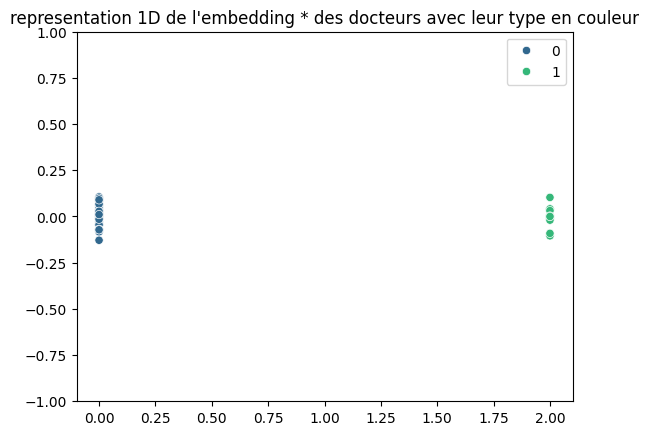

In [801]:
#Visualisation des clusters
sns.set_palette("deep") 

# La couleur représente le degré, c'est-à-dire le nombre de lien qu'a le docteur
sns.scatterplot( x= doctor_embedding_star, y= np.random.normal(0, 0.05, size=doctor_embedding_star.shape[0],), hue=psi_class, palette='viridis')
plt.title("representation 1D de l'embedding * des docteurs avec leur type en couleur")
plt.ylim(-1,1)
plt.show()

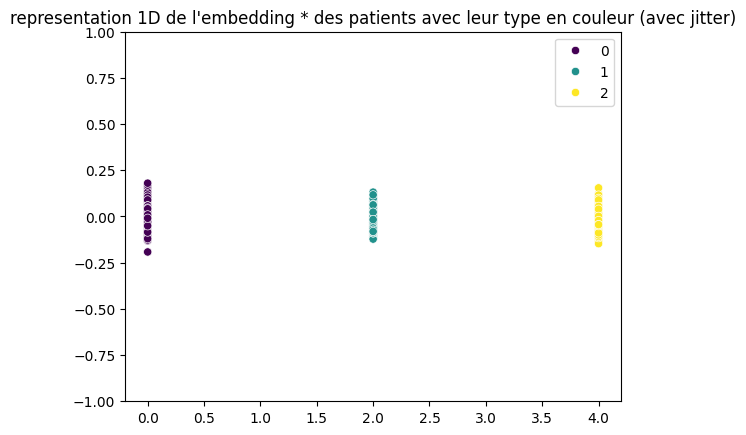

In [802]:
#Visualisation des clusters
sns.set_palette("deep") 

# La couleur représente le degré, c'est-à-dire le nombre de lien qu'a le docteur
sns.scatterplot( x= patient_embedding_star, y= np.random.normal(0, 0.05, size=patient_embedding_star.shape[0],), hue=alpha_class, palette='viridis')
plt.title("representation 1D de l'embedding * des patients avec leur type en couleur (avec jitter)")
plt.ylim(-1,1)

plt.show()

#### K-means

In [803]:
# Initialiser le modèle KMeans avec 4 clusters
kmeans_p_star = KMeans(n_clusters=3, random_state=0)
# Ajuster le modèle sur les données
kmeans_p_star.fit(patient_embedding_star.reshape(-1,1))
# Ajouter les labels prédits au DataFrame
cluster_patient_star = kmeans_p_star.labels_

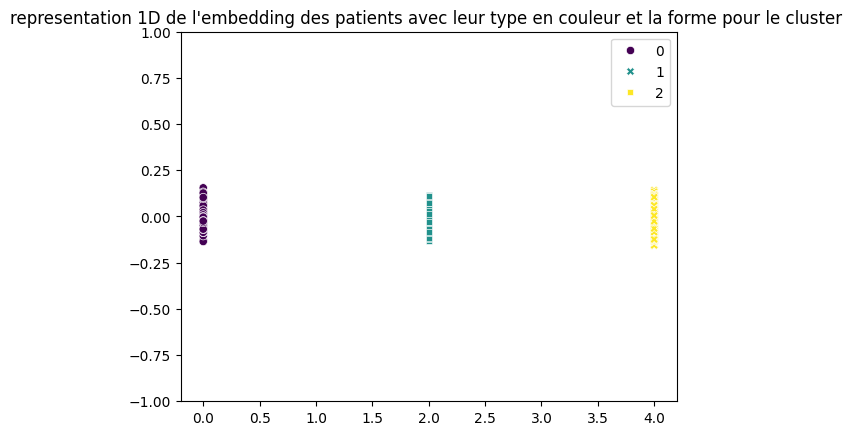

In [804]:
#Visualisation des clusters
sns.set_palette("deep") 

# La couleur représente le degré, c'est-à-dire le nombre de lien qu'a le docteur
sns.scatterplot( x= patient_embedding_star, y= np.random.normal(0, 0.05, size=patient_embedding_star.shape[0],), hue=alpha_class, style = cluster_patient_star, palette='viridis')
plt.title("representation 1D de l'embedding des patients avec leur type en couleur et la forme pour le cluster ")
plt.ylim(-1,1)
plt.show()

In [805]:
# Initialiser le modèle KMeans avec 4 clusters
kmeans_d_star = KMeans(n_clusters=2, random_state=1)
# Ajuster le modèle sur les données
kmeans_d_star.fit(doctor_embedding_star.reshape(-1,1))
# Ajouter les labels prédits au DataFrame
cluster_doctor_star = kmeans_d_star.labels_

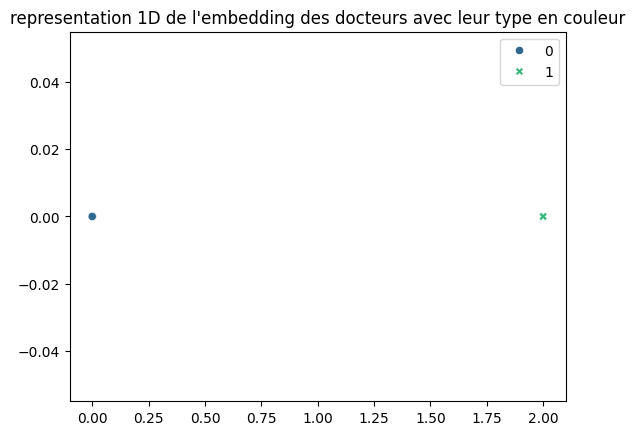

In [806]:
#Visualisation des clusters
sns.set_palette("deep") 

# La couleur représente le degré, c'est-à-dire le nombre de lien qu'a le docteur
sns.scatterplot( x= doctor_embedding_star, y= np.zeros(doctor_embedding_star.shape[0],), hue=psi_class, style=cluster_doctor_star, palette='viridis')
plt.title("representation 1D de l'embedding des docteurs avec leur type en couleur")

plt.show()

#### AMI Measure

Pour mesurer la performance de notre clustering, nous allons utiliser le "Adjusted Mutual Information score" qui est une version ajustée du "Mutual Information score" afin de ramener à 0 le score pour un clustering aléatoire.

Le Mutual Information score est une mesure de la similartité entre deux "labels" du même jeu de données.
Soient $|U_{i}|$ le nombre d'observations dans le cluster (ou la classe) $U_{i}$ et $|V_{j}|$ le nombre d'observations dans le cluster. Le Mutual Information socre entre les deux partitions de clusters $U$ et $V$ est donnée  par l'expression suivante:

$MI(U,V) = \sum_{i} \sum_{j} \frac{|U_{i} \cap V_{j}|}{N}log \frac{N|U_{i} \cap V_{j}|}{|U_{i}| |V_{j}|}$

où $N$ est le nombre total d'observations 

Notons que la métrique est symétrique et indépendante de toute permutation entre les clusters (le label 0, 1, 2 ou même n'importe quoi sur tel ou tel cluster n'a pas d'importance)

L'Ajusted Mutual Information est donné par la formule:

$ AMI(U, V) = \frac{MI(U, V) - E(MI(U, V))}{avg(H(U), H(V)) - E(MI(U, V))} $

où $H(.)$ est l'entropie, dont l'expression est $H(U) := - \sum_{i=1}^{R} \frac{|U_{i}|}{N} log \frac{|U_{i}|}{N}$

Source pour plus de détails:

https://en.wikipedia.org/wiki/Adjusted_mutual_information
https://scikit-learn.org/stable/modules/generated/sklearn.metrics.adjusted_mutual_info_score.html#sklearn.metrics.adjusted_mutual_info_score
https://jmlr.csail.mit.edu/papers/volume11/vinh10a/vinh10a.pdf

In [109]:
metric_doctor_star =  metrics.adjusted_rand_score(psi_class, cluster_doctor_star)
print(metric_doctor_star)

1.0


In [110]:
metric_patient_star =  metrics.adjusted_rand_score(alpha_class, cluster_patient_star)
print(metric_patient_star)

1.0


### Clustering sur l'Embedding estimé

In [744]:
patient_embedding_hat = np.array(ef_patient).flatten()
doctor_embedding_hat = np.array(ef_doctor).flatten()

#### Visualisation

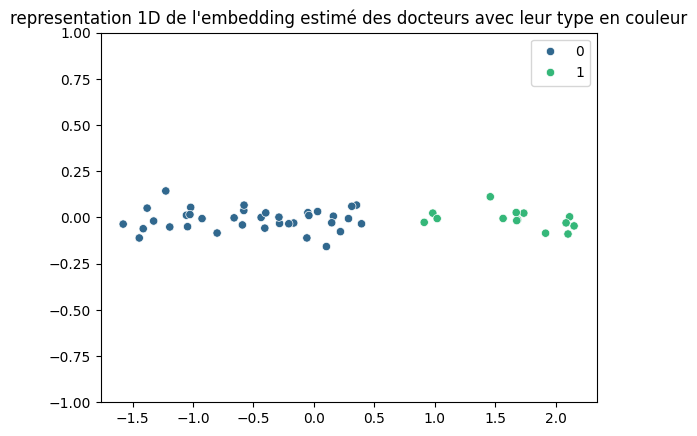

In [745]:
#Visualisation des clusters
sns.set_palette("deep") 

# La couleur représente le degré, c'est-à-dire le nombre de lien qu'a le docteur
sns.scatterplot( x= doctor_embedding_hat, y=np.random.normal(0, 0.05, size=doctor_embedding_hat.shape[0],), hue=psi_class, palette='viridis')
plt.title("representation 1D de l'embedding estimé des docteurs avec leur type en couleur")
plt.ylim(-1,1)
plt.show()

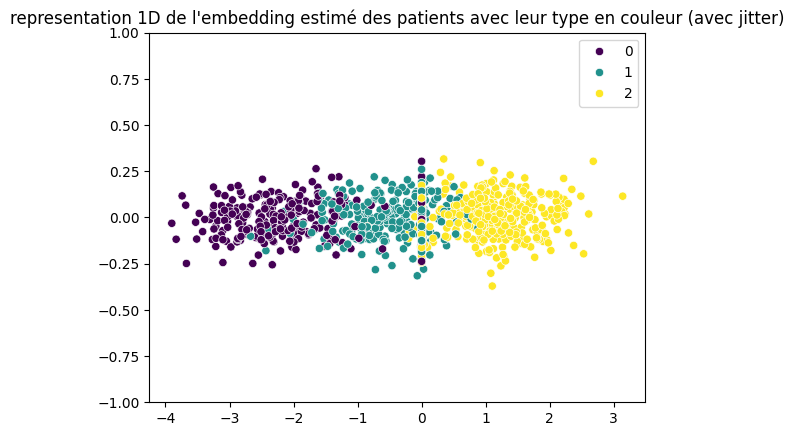

In [746]:
#Visualisation des clusters
sns.set_palette("deep") 

# La couleur représente le degré, c'est-à-dire le nombre de lien qu'a le docteur
sns.scatterplot( x= patient_embedding_hat, y= np.random.normal(0, 0.1, size=patient_embedding_hat.shape[0],), hue=alpha_class, palette='viridis')
plt.title("representation 1D de l'embedding estimé des patients avec leur type en couleur (avec jitter)")
plt.ylim(-1,1)

plt.show()

#### K-means

In [747]:
# Initialiser le modèle KMeans avec 4 clusters
kmeans_d_hat = KMeans(n_clusters=2, random_state=1)
# Ajuster le modèle sur les données
kmeans_d_hat.fit(doctor_embedding_hat.reshape(-1,1))
# Ajouter les labels prédits au DataFrame
cluster_doctor_hat = kmeans_d_hat.labels_

# Initialiser le modèle KMeans avec 4 clusters
kmeans_p_hat = KMeans(n_clusters=3, random_state=0)
# Ajuster le modèle sur les données
kmeans_p_hat.fit(patient_embedding_hat.reshape(-1,1))
# Ajouter les labels prédits au DataFrame
cluster_patient_hat = kmeans_p_hat.labels_

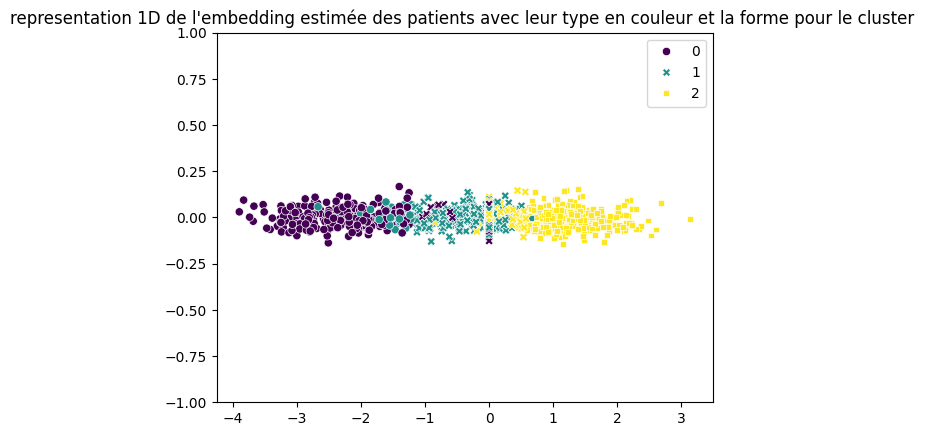

In [748]:
#Visualisation des clusters
sns.set_palette("deep") 

# La couleur représente le degré, c'est-à-dire le nombre de lien qu'a le docteur
sns.scatterplot( x= patient_embedding_hat, y= np.random.normal(0, 0.05, size=patient_embedding_hat.shape[0],), hue=alpha_class, style = cluster_patient_hat, palette='viridis')
plt.title("representation 1D de l'embedding estimée des patients avec leur type en couleur et la forme pour le cluster ")
plt.ylim(-1,1)
plt.show()

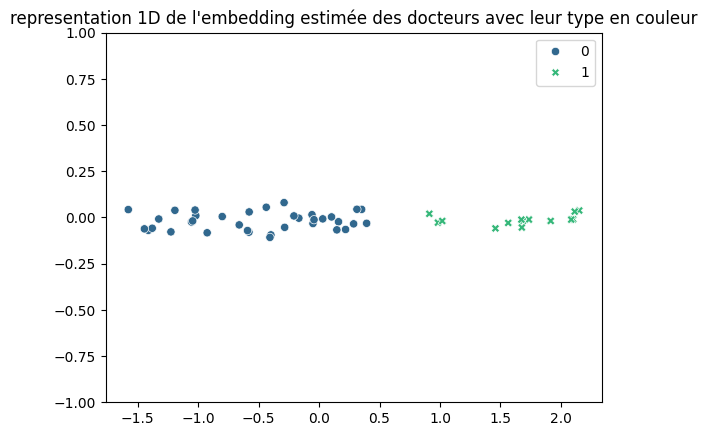

In [749]:
#Visualisation des clusters
sns.set_palette("deep") 

# La couleur représente le degré, c'est-à-dire le nombre de lien qu'a le docteur
sns.scatterplot( x= doctor_embedding_hat, y= np.random.normal(0, 0.05, size=doctor_embedding_hat.shape[0],), hue=psi_class, style=cluster_doctor_hat, palette='viridis')
plt.title("representation 1D de l'embedding estimée des docteurs avec leur type en couleur")
plt.ylim(-1,1)
plt.show()

#### AMI

Pour mesurer la performance de notre clustering, nous allons utiliser le "Adjusted Mutual Information score" qui est une version ajustée du "Mutual Information score" afin de ramener à 0 le score pour un clustering aléatoire.

Le Mutual Information score est une mesure de la similartité entre deux "labels" du même jeu de données.
Soient $|U_{i}|$ le nombre d'observations dans le cluster (ou la classe) $U_{i}$ et $|V_{j}|$ le nombre d'observations dans le cluster. Le Mutual Information socre entre les deux partitions de clusters $U$ et $V$ est donnée  par l'expression suivante:

$MI(U,V) = \sum_{i} \sum_{j} \frac{|U_{i} \cap V_{j}|}{N}log \frac{N|U_{i} \cap V_{j}|}{|U_{i}| |V_{j}|}$

où $N$ est le nombre total d'observations 

Notons que la métrique est symétrique et indépendante de toute permutation entre les clusters (le label 0, 1, 2 ou même n'importe quoi sur tel ou tel cluster n'a pas d'importance)

L'Ajusted Mutual Information est donné par la formule:

$ AMI(U, V) = \frac{MI(U, V) - E(MI(U, V))}{avg(H(U), H(V)) - E(MI(U, V))} $

où $H(.)$ est l'entropie, dont l'expression est $H(U) := - \sum_{i=1}^{R} \frac{|U_{i}|}{N} log \frac{|U_{i}|}{N}$

Source pour plus de détails:

https://en.wikipedia.org/wiki/Adjusted_mutual_information
https://scikit-learn.org/stable/modules/generated/sklearn.metrics.adjusted_mutual_info_score.html#sklearn.metrics.adjusted_mutual_info_score
https://jmlr.csail.mit.edu/papers/volume11/vinh10a/vinh10a.pdf

In [750]:
metric_doctor_hat =  metrics.adjusted_rand_score(psi_class, cluster_doctor_hat)
print(f"AMI du clsutering sur l'embedding estimé des docteurs: {metric_doctor_hat}")
metric_patient_hat =   metrics.adjusted_rand_score(alpha_class, cluster_patient_hat)
print(f"AMI du clsutering sur l'embedding estimé des patients: {metric_patient_hat}")

AMI du clsutering sur l'embedding estimé des docteurs: 1.0
AMI du clsutering sur l'embedding estimé des patients: 0.42453797297215357


## Etude de la qualité de prédiction du modèle MF (1D)

La fonction suivante divise les données en ensembles d'entraînement et de test, entraîne un modèle sur l'ensemble d'entraînement et évalue sa performance sur l'ensemble de test. Elle trace l'historique de l'entraînement, la matrice de confusion et imprime diverses métriques de performance telles que la précision, le rappel, le F1-score et l'erreur quadratique moyenne. La fonction imprime également les coefficients estimés (bêtas) et leurs erreurs par rapportaux paramètres réels de l'objet graph_object.

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Mean Squared Error sur l'échantillon de test : 0.2891640294620255
Precision: 0.80
Recall: 0.74
F1-score: 0.77
ESTIMATION BETA: X p [0.18478703]; X d [0.06713227]; D_p [1.5282815]; D_d [3.713906]; distance [-21.997194]
ERROR ESTIMATION BETA: X p [-0.01521297]; X d [-0.13286772]; D_p [0.52828145]; D_d [2.713906]; distance [3.0028057]


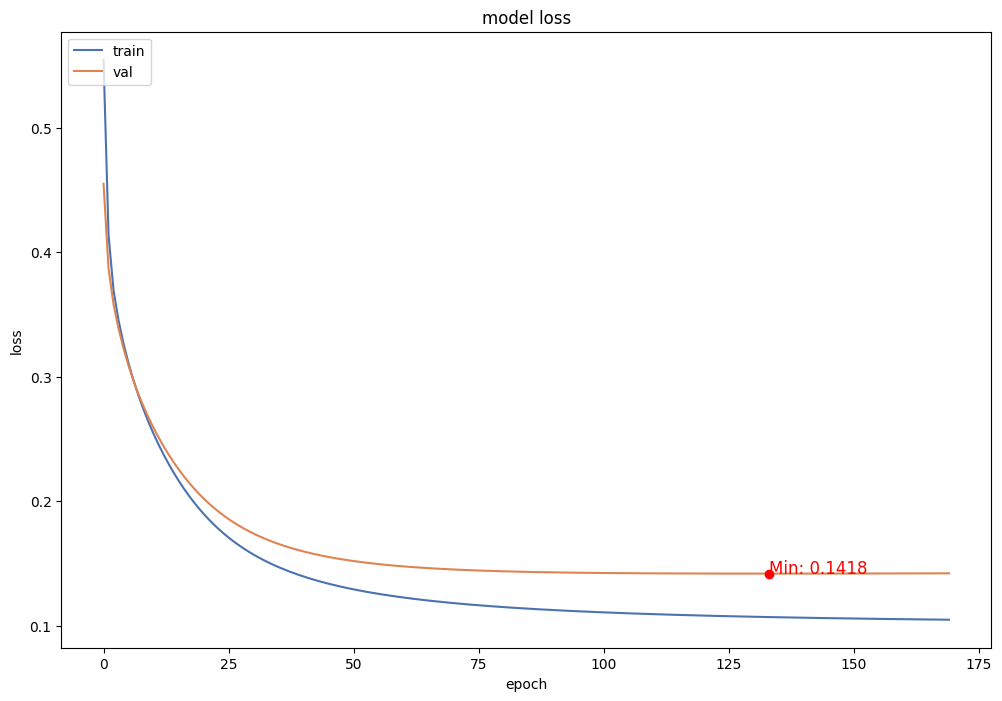

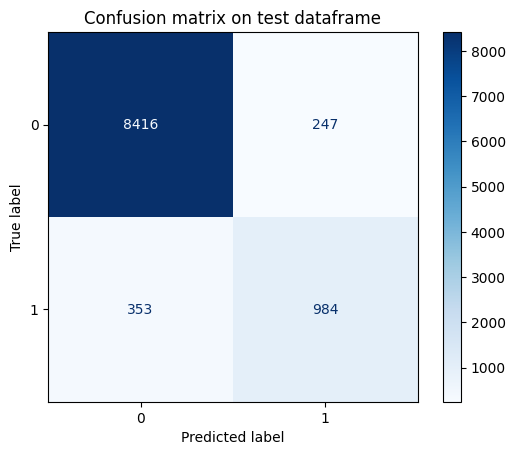

Temps d'exécution : 222 secondes


In [931]:
MF_HNS.prediction_score(graph_object, nb_epochs=170)

affichage de la matrice de confusion: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html

<span style="color:blue">**CONCLUSION:**</span> Nous pouvons constater que le modèle apprend plutôt bien, dans le sens où il prédit assez correctement les liens sur le jeu de test, bien que les classes de labels soient très désiquilibrées (90% de 0). Cela se remarque par les cases en en haut à droite et en bas à gauche qui sont équilibrées et le recall qui est élevé.

## Etude de l'évolution de loss et du RMSE à travers les epochs

Les cellules précédentes semblent montrer qu'il est inutile d'entrainer le modèle plus de 120 epochs. Le but des cellules suivantes est de vérifier si cela reste vrai même lorsque la densité du graphe est bien différente.
La fonction suivante simule des graphes pour chaque valeur de beta_distance dans `sim_beta_distance_array`.
Pour chaque graphe simulé, elle calcule la densité du graphe, affiche cette densité, et entraîne un modèle
avec les données du graphe en utilisant `prediction_score`. Cela permet de comparer les courbes de loss et les minimums.

In [ ]:
MF_HNS.loss_vs_density(sim_beta_distance_array = [-25,-17, -13,-10, -8, -5,-3], nb_epochs=140)

density of the graph: 13.44%


Par lecture graphique, il semblerait que le nombre d'epochs nécessaire avant d'atteindre le minimum sur la fonction de loss sur le jeu de validation diminue à mesure que la densité du graphe augmente. 
La fonction suivante trace l'évolution de l'erreur quadratique moyenne (RMSE) des effets fixes à travers les époques pour différentes valeurs de densité (qui varie via la variation du beta_distance). Cela nous permettra d'avoir une idée de comment le RMSE varie à travers les epoques, selon la densité du graphe. Nous pourrons alors avoir une idée du nombre d'époques idéal.

[4.90980447 4.40008833 3.98358314 3.70991092 3.52802195 3.400815
 3.30775525 3.23736957 3.18284355 3.13986245 3.10554694 3.07790517
 3.05549733 3.03726508]
[ 10  20  30  40  50  60  70  80  90 100 110 120 130 140]
[4.63436416 4.05243154 3.64067504 3.38815358 3.22611306 3.11586717
 3.03745585 2.97990354 2.93671057 2.90378004 2.87840465 2.85872297
 2.8434139  2.83151602]
[ 10  20  30  40  50  60  70  80  90 100 110 120 130 140]
[4.43745693 3.85257397 3.47628119 3.24978456 3.10450388 3.00571282
 2.93562576 2.88438131 2.84608368 2.81700925 2.79469407 2.77744569
 2.76406801 2.7537006 ]
[ 10  20  30  40  50  60  70  80  90 100 110 120 130 140]
[4.28004438 3.6909807  3.33417646 3.12306634 2.98909231 2.89912557
 2.83628399 2.79113134 2.75804547 2.73347329 2.71507142 2.70123865
 2.69084934 2.68309211]
[ 10  20  30  40  50  60  70  80  90 100 110 120 130 140]
[4.02192863 3.48326378 3.17312751 2.98535383 2.86337281 2.7800279
 2.72099905 2.67806271 2.64620216 2.62218713 2.60386997 2.58977497
 2.57

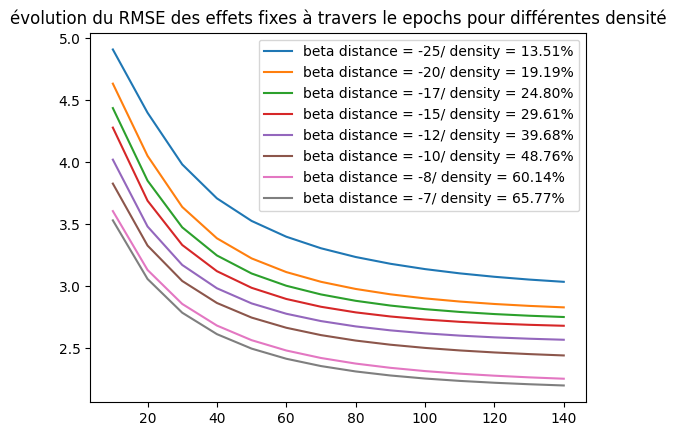

Temps d'exécution : 1827 secondes


In [24]:
# Temps d'exécution : 1827 secondes
density_ami_rmse_simulation.plot_rmse_epochs(n=14, save=True)

Il semble que même avec un nombre d'époques élevées, nous n'avons pas réussi à atteindre un plateau pour le RMSE. Réessayons pour une seule valeur de beta, mais avec 250 epoques:

[4.90420166 4.38907076 3.96931369 3.69492178 3.51373158 3.38793879
 3.29665503 3.22821384 3.17569393 3.13473624 3.10243496 3.07678079
 3.05632972 3.04001838 3.02704051 3.01678143 3.0087612  3.00259448
 2.99797884 2.99466384 2.99245099 2.99117763 2.99070634 2.99092002
 2.99172535]
[ 10  20  30  40  50  60  70  80  90 100 110 120 130 140 150 160 170 180
 190 200 210 220 230 240 250]


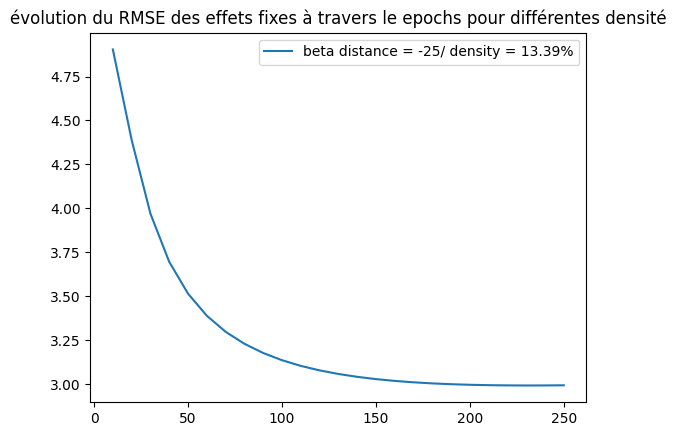

Temps d'exécution : 411 secondes


In [26]:
# Temps d'exécution : 411 secondes
density_ami_rmse_simulation.plot_rmse_epochs(n = 25, sim_beta_distance_array = [-25], save=True)

<span style="color:blue">**CONCLUSION:**</span> Nous constatons que quelque soit la densité du graphe, le RMSE continue de décroître, même après 140 époques. Il faudrait environ 200 epoques aux modèles pour arriver sur un plancher en terme de RMSE. Remarquons également qu'une plus grande densité du graphe conduit de façon clair à un RMSE plus faible. 

## Etude estimation des beta

Nous allons maintenant étudier l'estimation des beta par le modèle. Pour ce faire, nous allons créer 100 graphes différents (mais avec les mêmes paramètres par défault) et estimer les betas. Si nous obtenons des distrubtions normales centrée en la vraie valeur de beta pour les betas estimés, nous pourrons conclure que le modèle estime bien les betas

In [ ]:
simulation_beta.simulation_beta(n=100, nb_epochs=140)

Simulation 1: done !
Simulation 2: done !
Simulation 3: done !
Simulation 4: done !
Simulation 5: done !
Simulation 6: done !
Simulation 7: done !
Simulation 8: done !
Simulation 9: done !
Simulation 10: done !
Simulation 11: done !
Simulation 12: done !
Simulation 13: done !
Simulation 14: done !
Simulation 15: done !
Simulation 16: done !
Simulation 17: done !
Simulation 18: done !
Simulation 19: done !


## Etude de la robustesse avec du sampling

### simulation et plot

Cette fonction effectue n simulations en ré-échantillonnant aléatoirement les données et en séparant les données en ensembles d'entraînement et de test
selon le ratio spécifié. Pour chaque simulation, elle entraîne un modèle et stocke les estimations des paramètres dans des matrices. Ensuite, elle affiche
des histogrammes des estimations des paramètres avec des lignes indiquant les valeurs moyennes et les vraies valeurs des paramètres. Elle retourne également tout les paramètres estimés à travers les simulations (effets fixes, beta).

In [ ]:
%%capture captured_output
results = robustesse_simulation.robustesse_simul_n_models(100, 0.85, graph_object)
# Enregistrer le tuple sur le disque
with open('results_simulation_85.pkl', 'wb') as f:
    pickle.dump(results, f)

### score de similarité des matrices (robustesse des effets fixes)

Pour tester la robustesse des effets fixes, nous allons construire des matrices $A_{k}$ dont les composantes $(a_{ij}^{(k)})$ valent $|\alpha_{i}^{(k)} - \alpha_{j}^{(k)}|$   (ou $d(\alpha_{i}^{(k)},\alpha_{j}^{(k)})$ de façon plus général). Nous allons ensuite comparer la similarité entre ces matrices $A_{k}$.

In [872]:
# Charger la variable depuis le disque
with open('results_simulation_85.pkl', 'rb') as f:
    results_simulation = pickle.load(f)

In [873]:
distance_matrix_list_ef_patient_triangle = robustesse_simulation.make_list_dist_ef_matrix(results_simulation[0])
distance_matrix_list_ef_docteur_triangle = robustesse_simulation.make_list_dist_ef_matrix(results_simulation[1])

Les fonctions suivantes renvoient une matrice qui calculent la similarité entre les matrices de distance des effets fixes.

## RMSE vs density

Dans cette partie, nous nous intéressons à l'estimation des effets fixes en fonction de la densité du graphe. La littérature semble indiquer qu'une plus grande densité conduit à une meilleure estimation des EF. Nous mesurons dans un premier temps la qualité de l'estimation via le RMSE (root mean squared error) des EF:

$ RSME_{\alpha,\psi} =   [ \frac{1}{JI}  \sum_{i,j}  (\alpha_{i}^{*} + \psi_{j}^{*} - \hat{\alpha_{i}} - \hat{\psi_{j}})^{2}   ]^{\frac{1}{2}}   $

In [ ]:
%%time
results = density_ami_rmse_simulation.plot_rmsedensity()

In [808]:
%%capture captured_output
matrix_sim_ami, time = simulation_confidence_interval(n=100, sim_beta_distance_array = [-15,-12,-10,-8,-7,-5,-3], nb_epochs=80, n_patients = 100, n_doctors=100 )
with open('matrix_simulation_ami_symetric.npy', 'wb') as f:
    np.save(f, matrix_sim_ami)

TypeError: 'module' object is not callable

In [440]:
with open('matrix_simulation_ami.npy', 'rb') as f:
    matrix_simulation_ami = np.load(f)

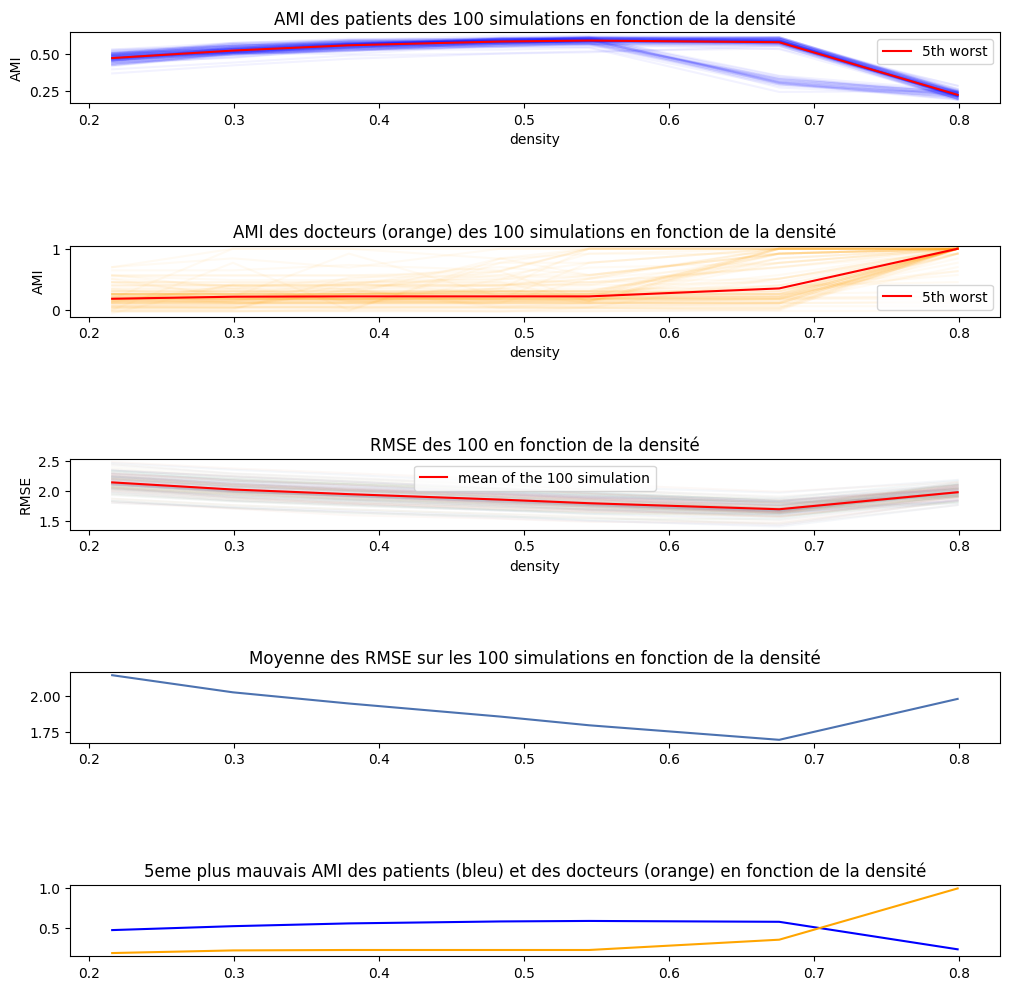

In [753]:
plot_hist_simulation_density_ami(matrix_simulation_ami,rank=7)

## RMSE vs lambda_regularisation

In [90]:
def plot_rmsemlambda( regu_lambda = np.array([10**(-i) for i in range(5,9)]), regularization="l2" ):
    
    beta_skilled_d, beta_age_d, beta_informed_p, beta_age_p, beta_distance = np.zeros(len(regu_lambda)), np.zeros(len(regu_lambda)), np.zeros(len(regu_lambda)), np.zeros(len(regu_lambda)) ,np.zeros(len(regu_lambda))
    rmse_array, rmse_alpha_array, rmse_psi_array = np.zeros(len(regu_lambda)), np.zeros(len(regu_lambda)), np.zeros(len(regu_lambda))
    for i,regu_lambda_ in enumerate(regu_lambda):
        graph_all= graph_formation(
                    n_patients=1000,
                     n_doctors=50,
                     max_number_connections=20,
                     z=1.4,
                     seed=i)
        df, alpha_star, psi_star, alpha_class, psi_class, coor_patients, coor_doctors, D, beta_age_p_star, beta_age_d_star, beta_informed_p_star,\
        beta_skilled_d_star, beta_distance_star, sim_patient_age_normed, sim_doctor_age_normed, sim_patient_informed, sim_doctor_skilled = graph_all


        
        df['age_p'] = (df['age_p'] - df['age_p'].mean())/df['age_p'].std()
        df['age_d'] = (df['age_d'] - df['age_d'].mean())/df['age_d'].std()
        
        estimates =  get_estimations(df, nb_epochs=100, initial_weights=None, target_loss=None, show_print=0, seed=i, l_lambda = regu_lambda_, regularization="l2")
        alpha_hat = np.array(estimates[1][0])
        psi_hat = np.array(estimates[1][1])
        beta_age_p[i] = estimates[1][2][0]
        beta_age_d[i] = estimates[1][3][0]
        beta_informed_p[i] = estimates[1][4][0]
        beta_skilled_d[i] = estimates[1][5][0]
        beta_distance[i] = estimates[1][6][0]
        print(beta_age_p[i]-0.1, beta_age_d[i]-0.1, beta_informed_p[i]-1, beta_skilled_d[i]-1, beta_distance[i] + 20)  

        rmse_array[i] = rmse(alpha_hat, psi_hat, alpha_star, psi_star)[0]
        rmse_alpha_array[i] = rmse_alpha(alpha_hat, alpha_star)[0]
        rmse_psi_array[i] = rmse_psi(psi_hat, psi_star)[0]

    plt.title(f"Rmse en fonction du lambda (10^(-i) pour l'échelle) de régularization " + regularization)
    plt.plot(np.arange(len(regu_lambda)), rmse_array, label="Global RMSE")
    plt.plot(np.arange(len(regu_lambda)), rmse_alpha_array, label="RMSE of psi")
    plt.plot(np.arange(len(regu_lambda)), rmse_psi_array, label="RMSE of alpha")
    plt.legend()
    plt.show()    
    return beta_age_p, beta_age_d, beta_informed_p, beta_skilled_d, beta_distance

/tmp/ipykernel_210/1362294451.py:58: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  y = df['y'].values.astype(np.float32)
/opt/conda/lib/python3.12/site-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


0.03500083982944488 -0.2015898808836937 0.27116823196411133 1.5797207355499268 3.8901309967041016


/tmp/ipykernel_210/1362294451.py:58: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  y = df['y'].values.astype(np.float32)
/opt/conda/lib/python3.12/site-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


0.06574487090110778 0.0659901738166809 0.45059502124786377 2.041222333908081 2.629730224609375


/tmp/ipykernel_210/1362294451.py:58: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  y = df['y'].values.astype(np.float32)
/opt/conda/lib/python3.12/site-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


0.08865783512592315 0.13700614273548126 0.44799256324768066 1.3782083988189697 2.7816390991210938


/tmp/ipykernel_210/1362294451.py:58: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  y = df['y'].values.astype(np.float32)
/opt/conda/lib/python3.12/site-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


0.06471874713897705 -0.16460851430892945 0.41283559799194336 1.8801414966583252 2.8830528259277344


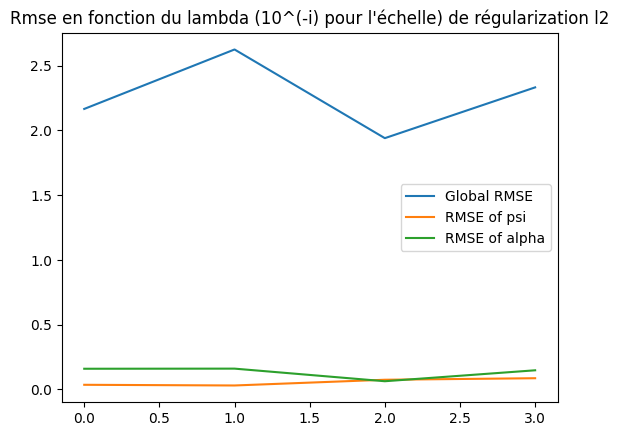

CPU times: user 7min 33s, sys: 1min 13s, total: 8min 46s
Wall time: 5min 1s


In [91]:
%%time
beta = plot_rmsemlambda()

0.08183138966560363 0.123225399851799 0.30364370346069336 0.5662616491317749 9.180665969848633
0.029662916064262385 0.04567990601062774 0.3114452362060547 0.5857946872711182 8.964532852172852
0.07957353591918945 -0.0036223441362381037 0.47260427474975586 0.25771868228912354 9.27706527709961
0.06344206035137176 0.04337113499641418 0.21791982650756836 0.7090258598327637 8.522601127624512
0.09606873393058776 0.06567395627498626 0.14309823513031006 1.3770074844360352 5.829246520996094
0.11306389570236205 0.0733580082654953 0.30832719802856445 1.4848453998565674 3.1041259765625
0.07872031033039092 0.30816450119018557 0.6088073253631592 1.612180471420288 2.0755367279052734
0.05445019304752349 -0.15384278297424317 0.4178506135940552 1.680147647857666 2.1788978576660156
0.02119512259960174 0.08430033326148986 0.4303908348083496 1.8415772914886475 1.7825241088867188


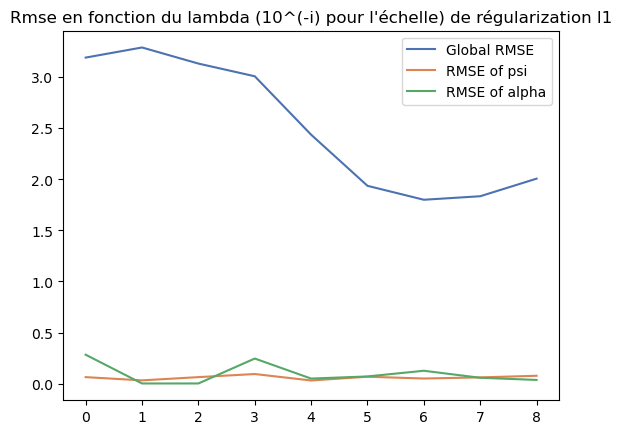

CPU times: total: 2min 33s
Wall time: 15min 33s


In [308]:
%%time
beta = plot_rmsemlambda(regularization='l1')

## Panel

### création des données panel

In [455]:
def make_panel_df(T=5, 
                  n_patients=1000,
                    n_doctors=50,
                    max_number_connections=50,
                    z=1.42 ):

    graph_all= graph_formation(
                    n_patients=n_patients,
                     n_doctors=n_doctors,
                     max_number_connections=max_number_connections,
                     z=z )
    panel_df, alpha_graph, psi_graph, alpha_class, psi_class, coor_patients, coor_doctors, D, beta_age_p_star, beta_age_d_star, beta_informed_p_star,\
    beta_skilled_d_star, beta_distance_star, sim_patient_age_normed, sim_doctor_age_normed, sim_patient_informed, sim_doctor_skilled = graph_all
    panel_df['y'] = panel_df['y'].astype("int")
    panel_df['period'] = np.zeros(n_patients*n_doctors)
    # Compile ids
    id_p = np.repeat(range(n_patients), n_doctors)
    id_d = np.tile(range(n_doctors), n_patients)
   
    for t in range(1,T):
        
        A = np.zeros([n_patients, n_doctors], dtype = np.ndarray)
        for i in range(n_patients):
            for j in range(n_doctors):
                if D[i][j] <= z: # if patient i and doctor j are too far away, there is no relation
                    doctor_data = panel_df[panel_df['j']==j]
                    patient_data = panel_df[panel_df['i']==i] 
                    T = alpha_graph[i] + psi_graph[j] + beta_age_p_star * sim_patient_age_normed[i] + beta_age_d_star * sim_doctor_age_normed[j] \
                        + beta_informed_p_star * sim_patient_informed[i] + beta_skilled_d_star * sim_doctor_skilled[j] + beta_distance_star * D[i][j]
                    p = 1 / (1 + np.exp(-T))
                    # P[i][j] = p
                    A[i][j] = np.random.binomial(1, p)
             # Compile relations between doctors and patients
        relation = A.flatten()
        # Merge all columns into a dataframe
        indices = n_doctors * n_patients
        df = pd.DataFrame(data={'i': id_p, 'j': id_d, 'y' : relation, 'age_p': panel_df['age_p'].head(indices) , 'age_d': panel_df['age_d'].head(indices), 
                           'informed_p': panel_df['informed_p'].head(indices), 'skilled_d': panel_df['skilled_d'].head(indices), 'class_p': panel_df['class_p'].head(indices), 'class_d': panel_df['class_d'].head(indices),
                             "distance": panel_df["distance"].head(indices), "ef_p_0": panel_df["ef_p_0"].head(indices), "ef_d_0": panel_df["ef_d_0"].head(indices),    
                                "period":np.ones(n_doctors*n_patients)*t
                            })
            
        panel_df = pd.concat([panel_df, df], ignore_index=True)
    return panel_df
    

In [456]:
panel_df = make_panel_df(T=5)

In [457]:
panel_df['y'] = panel_df['y'].astype("int")
panel_df[(panel_df["j"]==4) & (panel_df['i']==5)]

/opt/conda/lib/python3.12/site-packages/IPython/core/formatters.py:347: FutureWarning: Index.format is deprecated and will be removed in a future version. Convert using index.astype(str) or index.map(formatter) instead.
  return method()


,i,j,y,age_p,age_d,informed_p,skilled_d,class_p,class_d,distance,ef_p_0,ef_d_0,period
254,5,4,0,19,63,0,1,1,0,0.37474,2.0,0.0,0.0
50254,5,4,0,19,63,0,1,1,0,0.37474,2.0,0.0,1.0
100254,5,4,0,19,63,0,1,1,0,0.37474,2.0,0.0,2.0
150254,5,4,0,19,63,0,1,1,0,0.37474,2.0,0.0,3.0
200254,5,4,0,19,63,0,1,1,0,0.37474,2.0,0.0,4.0


In [458]:
panel_df['age_p'] = (panel_df['age_p']-panel_df['age_p'].mean())/panel_df['age_p'].std()
panel_df['age_d'] = (panel_df['age_d']-panel_df['age_d'].mean())/panel_df['age_d'].std()

### Score de prédiction panel

In [157]:
# On prend 80% du dataframe
train_indices = int(panel_df.shape[0]*0.8)
# L'argument drop=True permet de ne pas ajouter l'ancien index comme colonne supplémentaire dans le DataFrame
panel_shuffled = panel_df.sample(frac=1).reset_index(drop=True)
panel_train ,panel_test = panel_shuffled.iloc[:train_indices,:] , panel_shuffled.iloc[train_indices:,:]

In [158]:
estimates = get_estimations(panel_train, nb_epochs=60, initial_weights=None, target_loss=None, show_print=0, regularization="l2")
model_panel = estimates[4]
history_panel = estimates[5]
loss = estimates[0]

/opt/conda/lib/python3.12/site-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


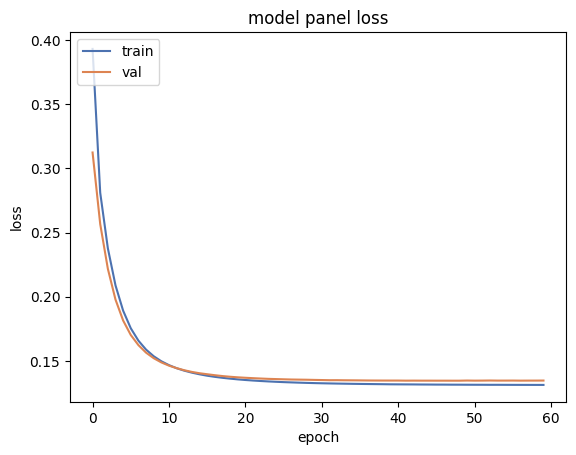

In [159]:
plt.plot(history_panel.history["loss"])
plt.plot(history_panel.history["val_loss"])
plt.title("model panel loss")
plt.ylabel("loss")
plt.xlabel("epoch")
plt.legend(["train", "val"], loc="upper left")
plt.show()

In [160]:
# Drop unwanted columns
X_test = panel_test.drop(['y', 'class_p', 'class_d', 'ef_p_0', 'ef_d_0', 'period'], axis=1)

# Assurez-vous que les colonnes sont dans le bon ordre
input_data = [tf.constant(X_test[col].values.reshape(-1, 1), dtype=tf.float32) for col in X_test.columns]

# Predict
results = model_panel.predict(input_data)

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step


In [161]:
y_true = panel_test['y'].values.astype(int)
y_pred =  (results.flatten() > 0.5).astype(int)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
mse = np.sum((results.flatten()-panel_test['y'])**2)/1500
print(f"Mean Squared Error sur l'échantillon de test : {mse}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-score: {f1:.2f}")

Mean Squared Error sur l'échantillon de test : 1.3863017721104849
Precision: 0.80
Recall: 0.73
F1-score: 0.76


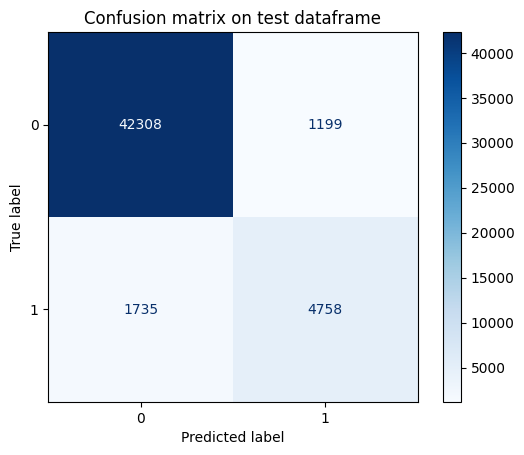

In [162]:
# Calculer la matrice de confusion
cm = confusion_matrix(y_true, y_pred)
# Affiche la matrice de confusion
disp = ConfusionMatrixDisplay(confusion_matrix=cm,)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion matrix on test dataframe")
plt.show()

### estimation des paramètres

In [461]:
estimates = get_estimations(panel_df, nb_epochs=60, initial_weights=None, target_loss=None, show_print=0)
ef_patient = estimates[1][0]
ef_doctor = estimates[1][1]
beta_age_p = estimates[1][2]
beta_age_d = estimates[1][3]
beta_informed_p = estimates[1][4]
beta_skilled_d = estimates[1][5]
beta_distance = estimates[1][6]

In [462]:
print(f"ESTIMATION BETA: age p {beta_age_p}; age d {beta_age_d}; informed {beta_informed_p}; skilled {beta_skilled_d}; distance {beta_distance}")
print(f"ERROR ESTIMATION BETA: age p {beta_age_p-0.2}; age d {beta_age_d-0.2}; informed {beta_informed_p-1}; skilled {beta_skilled_d-1}; distance {beta_distance+20}")

ESTIMATION BETA: age p [0.2120851]; age d [-0.04403578]; informed [1.4291133]; skilled [3.3869033]; distance [-19.916246]
ERROR ESTIMATION BETA: age p [0.0120851]; age d [-0.24403578]; informed [0.42911327]; skilled [2.3869033]; distance [0.08375359]


(array([12.,  8.,  0.,  0.,  8., 10.,  5.,  0.,  1.,  6.]),
 array([-0.60040855, -0.10440449,  0.39159957,  0.88760364,  1.38360763,
         1.87961173,  2.37561584,  2.87161994,  3.36762381,  3.86362791,
         4.35963202]),
 <BarContainer object of 10 artists>)

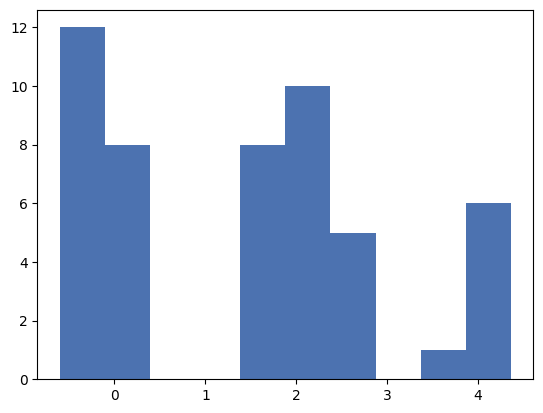

In [472]:
plt.hist(ef_doctor)

(array([ 11.,  79., 140.,  65.,  81., 171.,  51.,  97., 248.,  57.]),
 array([-4.15021038, -3.47245574, -2.79470134, -2.1169467 , -1.43919218,
        -0.76143765, -0.08368311,  0.59407145,  1.27182603,  1.94958055,
         2.62733507]),
 <BarContainer object of 10 artists>)

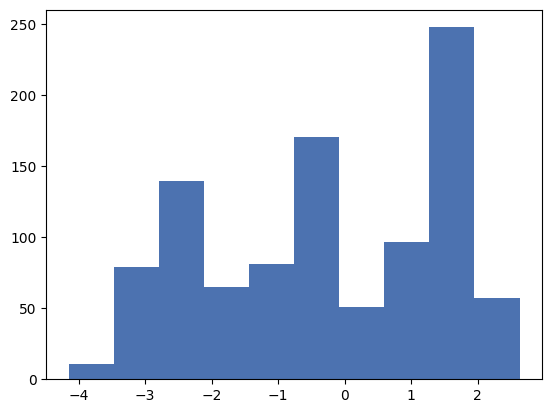

In [473]:
plt.hist(ef_patient)

## Estimation using pytwoway

Version de python utilisé pour pytwoway : 3.10 (3.10.12 or 3.10.13 is fine). 

In [ ]:
#!pip install pytwoway 
import pytwoway as tw

Estimation using pytwoway. You might want to use 3.10.12 Python version in order to install pytwoway as there are problems installing it using latest Python versions (see https://github.com/arthursabre/Stage-2A/blob/main/requirements.txt for all the versions of my packages used during the implementation).

In [1]:
df['y'] = df['y'].astype("float")

NameError: name 'df' is not defined

In [ ]:
def cost_estimate_pytwoway(df,
                           type_distance='default',
                           preconditioner='ichol'):

    fecontrol_params = tw.fecontrol_params(
    {
        'ho': True,
        'he': False,
        'feonly': True,
        'continuous_controls': ['distance', 'age_d', 'age_p'],
        'categorical_controls': ['sex_p', 'sex_d'],
        'attach_fe_estimates': True,
        'ncore': 8,
        'preconditioner': preconditioner # It looks like it gives better results (especially for large datasets ?)
    }
    )

    clean_params = bpd.clean_params(
    {
        'connectedness': 'leave_out_spell',
        'collapse_at_connectedness_measure': True,
        'drop_single_stayers': True,
        'drop_returns': 'returners',
        'copy': False
    }
    )

    dataframe = df.copy()
    # Scale specific columns
    dataframe['age_p'] =( dataframe['age_p'] - dataframe['age_p'].mean() ) / dataframe['age_p'].std()
    dataframe['age_d'] =( dataframe['age_d'] - dataframe['age_d'].mean() ) / dataframe['age_d'].std()
     # Change dtype of categorical variables
    dataframe['sex_p'] = dataframe['sex_p'].astype("category")
    dataframe['sex_d'] = dataframe['sex_d'].astype("category")
    # We create a BipartiteDataFrame in order to estimate the FE for the cost model
    if type_distance == 'default':
        
        bdf = bpd.BipartiteDataFrame(dataframe.drop(['ef_p_0', 'ef_d_0', "class_d", "class_p"] , axis = 1),
                                    custom_categorical_dict = {'sex_p': True,
                                                            'sex_d': True},
                                    custom_dtype_dict = {'sex_p': 'categorical',
                                                        'sex_d': 'categorical'},
                                    custom_how_collapse_dict = {'sex_p': 'first',
                                                                'sex_d': 'first'}) # We transform the dataframe as BipartitePandas dataframe to Estimate the FE.
    else:
        
        bdf = bpd.BipartiteDataFrame(dataframe.drop(['ef_p_0', 'ef_d_0', "class_d", "class_p", 'code_patient', 'code_doctor'] , axis = 1),
                                    custom_categorical_dict = {'sex_p': True,
                                                            'sex_d': True},
                                    custom_dtype_dict = {'sex_p': 'categorical',
                                                        'sex_d': 'categorical'},
                                    custom_how_collapse_dict = {'sex_p': 'first',
                                                                'sex_d': 'first'}) # We transform the dataframe as BipartitePandas dataframe to Estimate the FE.


    bdf.clean(clean_params)
    fe_estimator = tw.FEControlEstimator(bdf, fecontrol_params)
    fe_estimator.fit()

    return fe_estimator.gamma_hat_dict # Estimates of the EF, Beta for the cost model

In [ ]:
cost_estimates_pytwoway